# Chapter 4 — Temporal Evolution of AI Communication

Tracks how disclosure archetypes and dimension scores evolved from 2021 to 2025,
with event markers for ChatGPT (Nov 2022), SEC guidance (Mar 2024), and DeepSeek (Jan 2025).

**Requires:** `clustering_archetypes.ipynb` must have been run first.

In [7]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
DATA = Path('../data')

clusters = pd.read_parquet(DATA / 'processed/clusters/firm_year_clusters.parquet')
features = pd.read_parquet(DATA / 'processed/features/firm_year_features.parquet')

DIM_COLS = [c for c in clusters.columns if c.startswith('D') and c[1].isdigit()]
print(f'Loaded: {clusters.shape}  |  years: {sorted(clusters["year"].unique())}')
print(f'Archetypes: {sorted(clusters["cluster_name"].unique())}')
print(f'Dimension columns: {DIM_COLS}')


Loaded: (658, 22)  |  years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Archetypes: ['Boilerplate Risk-Warners', 'Governance & Compliance-Focused', 'Non-AI Disclosers', 'Operational Application Adopters', 'Promotional AI Claimants']
Dimension columns: ['D1 AI Intensity', 'D2 Operational', 'D3 Technical', 'D4 Quantification', 'D5 Governance', 'D6 Risk Depth', 'D7 Promotional', 'D8 Defensive', 'D9 Risk-section', 'D9 Substantive-section']


## 1. Archetype share by year (stacked area)

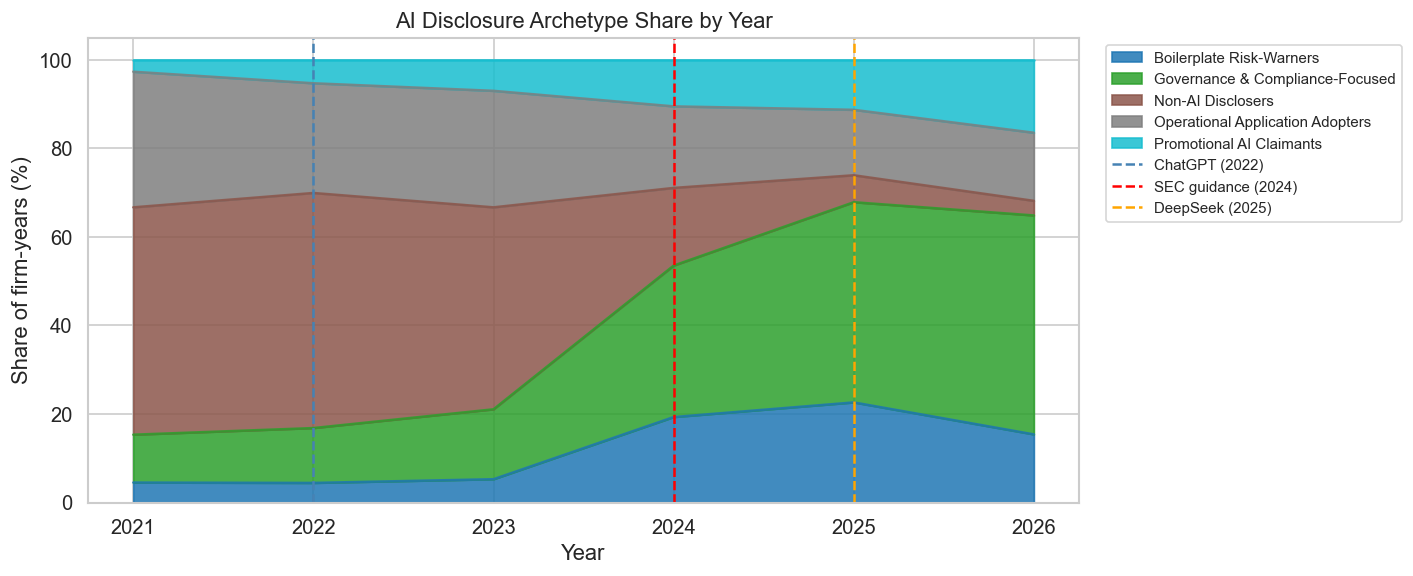

cluster_name  Boilerplate Risk-Warners  Governance & Compliance-Focused  Non-AI Disclosers  Operational Application Adopters  Promotional AI Claimants
year                                                                                                                                                  
2021                               4.5                             10.8               51.4                              30.6                       2.7
2022                               4.4                             12.4               53.1                              24.8                       5.3
2023                               5.3                             15.8               45.6                              26.3                       7.0
2024                              19.3                             34.2               17.5                              18.4                      10.5
2025                              22.6                             45.2                6.1    

In [8]:
EVENTS = {2022: ('ChatGPT', 'steelblue'), 2024: ('SEC guidance', 'red'), 2025: ('DeepSeek', 'orange')}

yr_ct = (
    clusters.groupby(['year', 'cluster_name'])
    .size().reset_index(name='n')
    .pivot(index='year', columns='cluster_name', values='n')
    .fillna(0)
)
yr_pct = yr_ct.div(yr_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
yr_pct.plot(kind='area', stacked=True, ax=ax, colormap='tab10', alpha=0.85)
for yr, (label, color) in EVENTS.items():
    if yr in yr_pct.index:
        ax.axvline(yr, color=color, linestyle='--', linewidth=1.5, label=f'{label} ({yr})')
ax.set_xlabel('Year')
ax.set_ylabel('Share of firm-years (%)')
ax.set_title('AI Disclosure Archetype Share by Year')
ax.set_xticks(sorted(yr_pct.index))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
Path('../reports').mkdir(exist_ok=True)
plt.savefig('../reports/archetype_share_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(yr_pct.round(1).to_string())


## 2. Dimension score trajectories per archetype

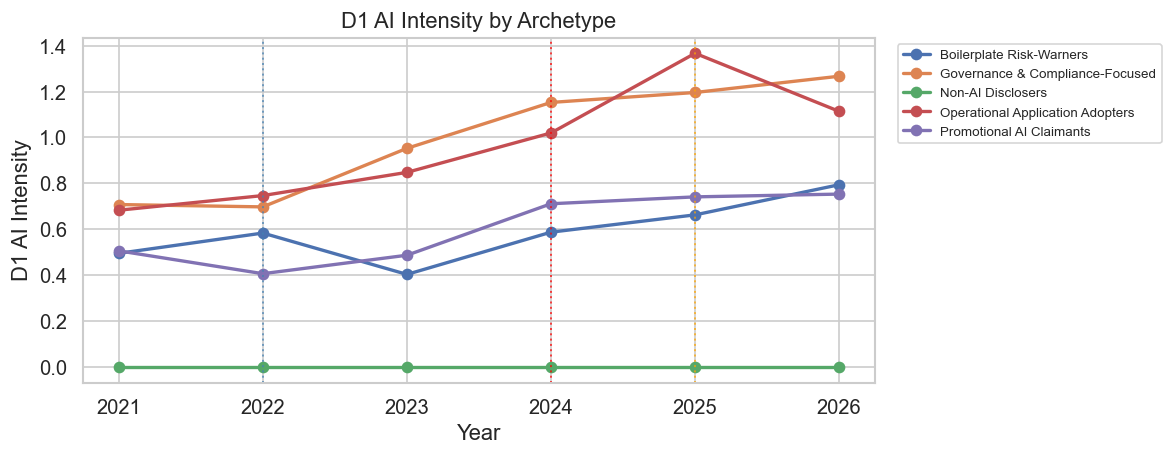

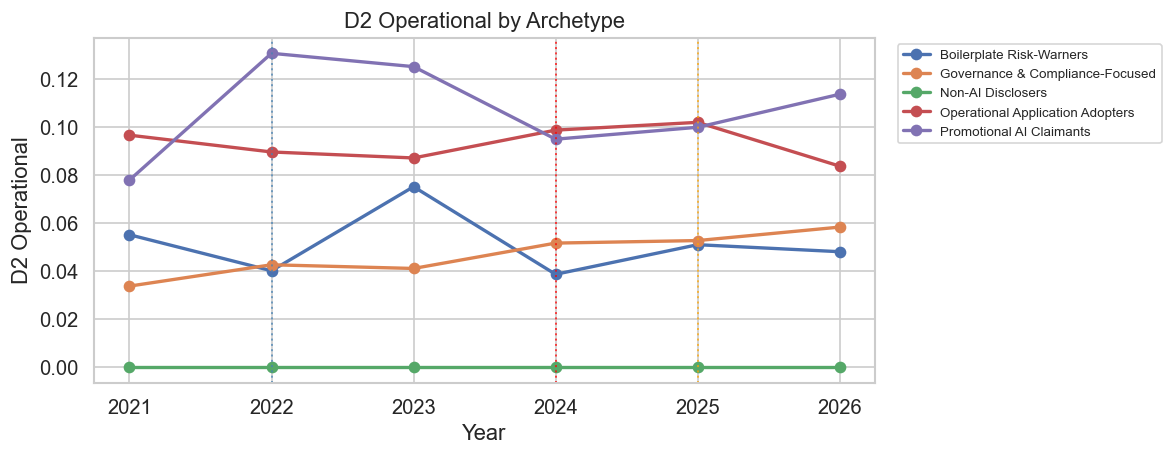

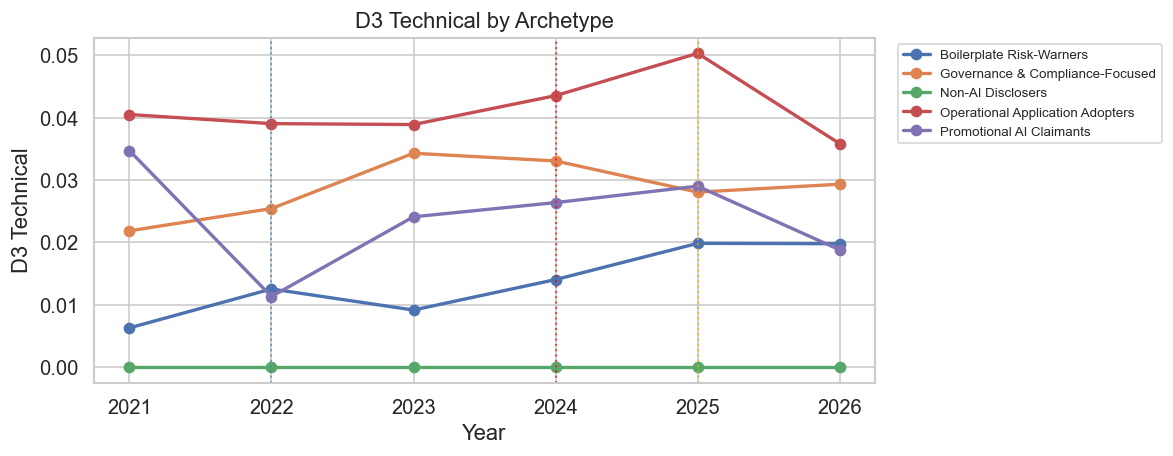

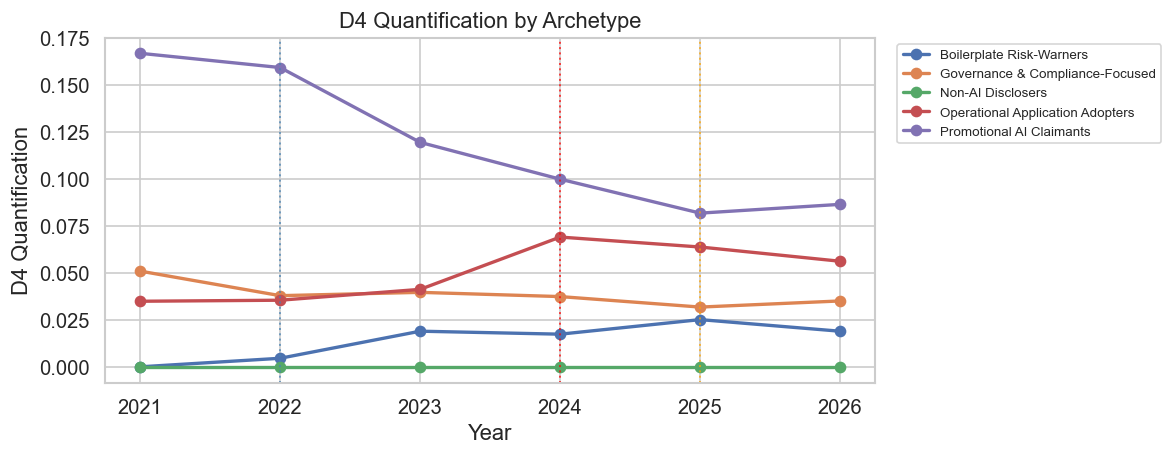

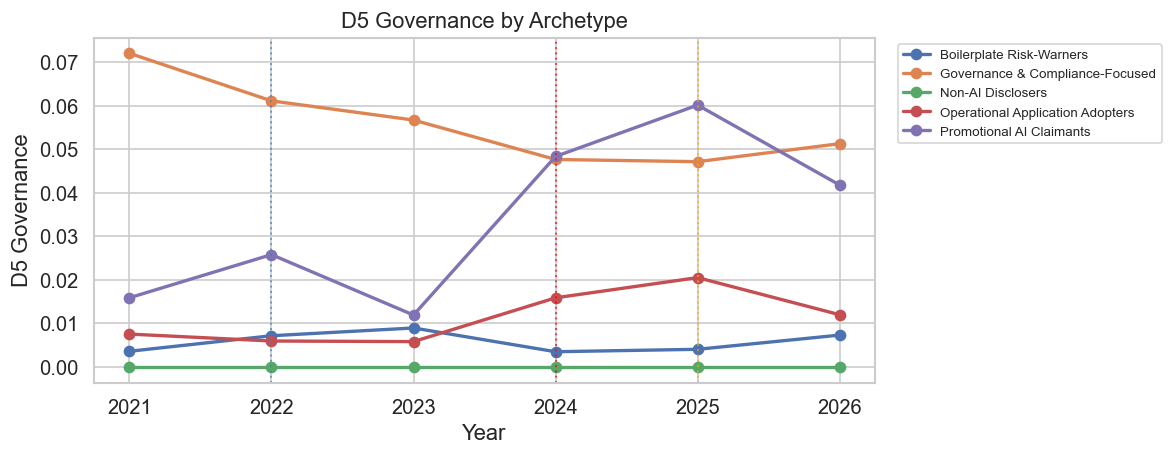

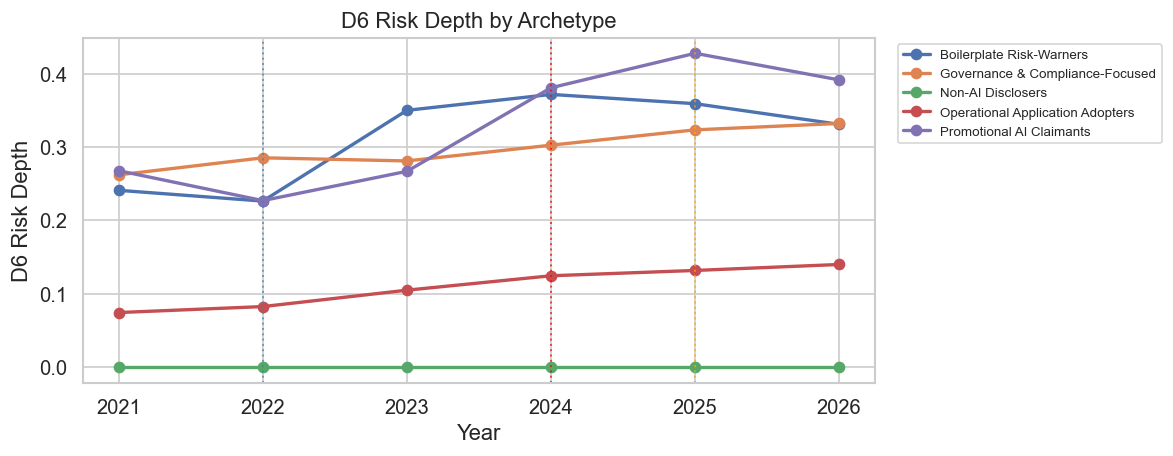

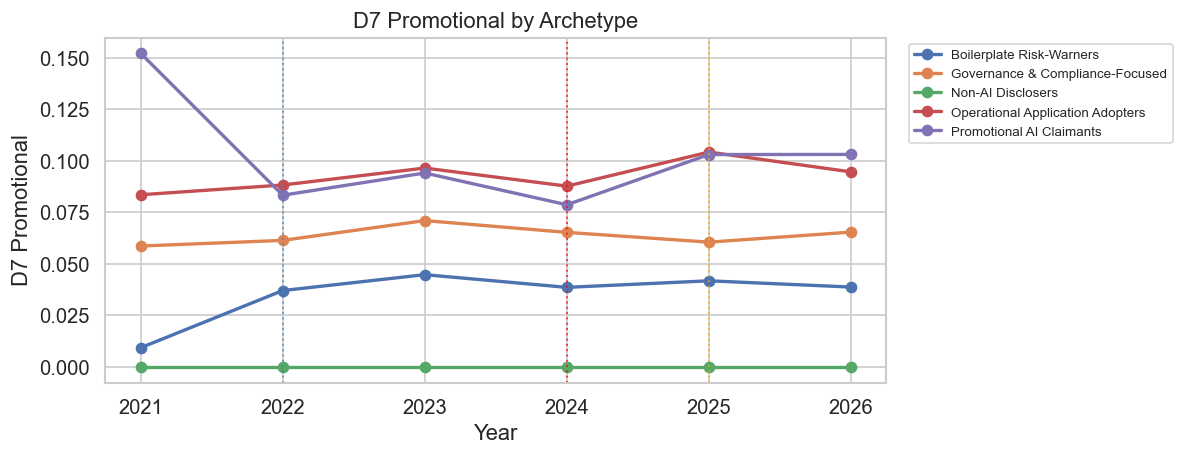

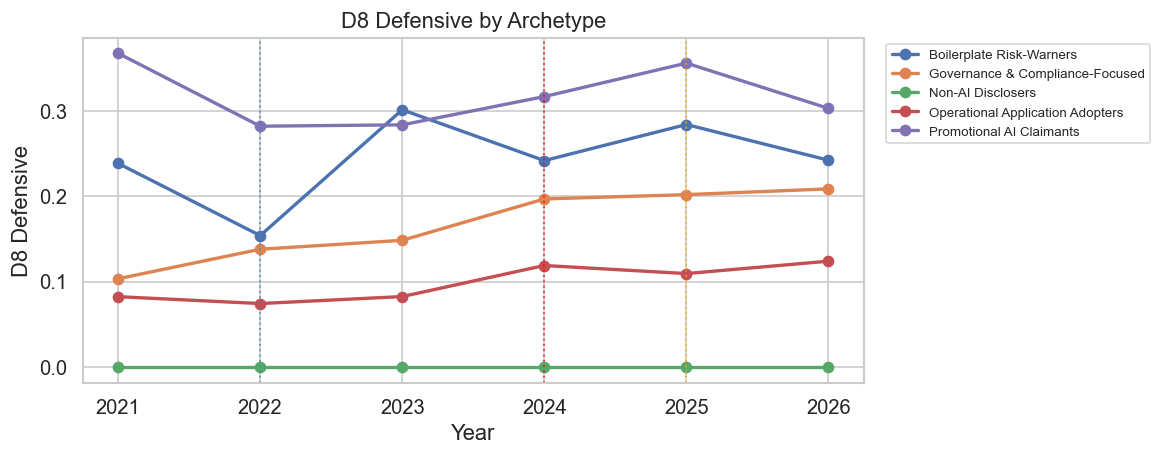

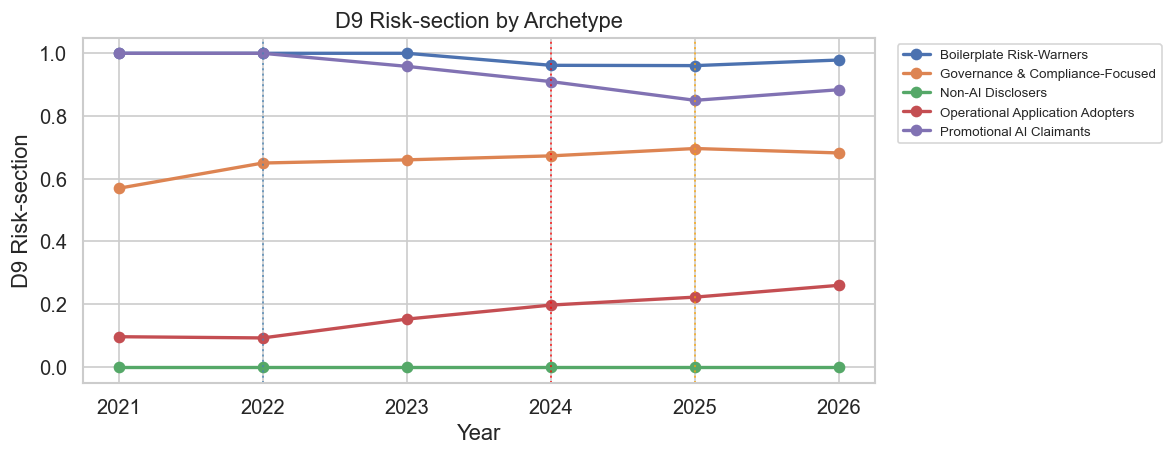

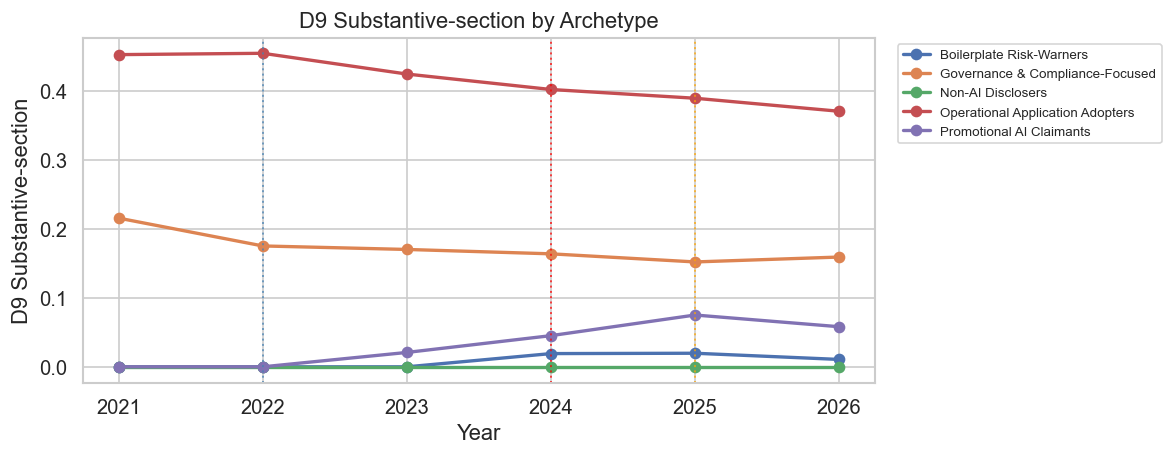

In [9]:
dim_map = {c: c.split(' ', 1)[1] if ' ' in c else c for c in DIM_COLS}

for dim in DIM_COLS:
    trend = clusters.groupby(['year', 'cluster_name'])[dim].mean().reset_index()
    if trend[dim].std() < 0.001:
        continue

    fig, ax = plt.subplots(figsize=(10, 4))
    for name, grp in trend.groupby('cluster_name'):
        grp = grp.sort_values('year')
        ax.plot(grp['year'], grp[dim], marker='o', linewidth=2, label=name)
    for yr, (label, color) in EVENTS.items():
        ax.axvline(yr, color=color, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f'{dim} by Archetype')
    ax.set_xlabel('Year'); ax.set_ylabel(dim)
    ax.set_xticks(sorted(trend['year'].unique()))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'../reports/dim_trend_{dim.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()


## 3. Pre/post event dimension shifts per archetype

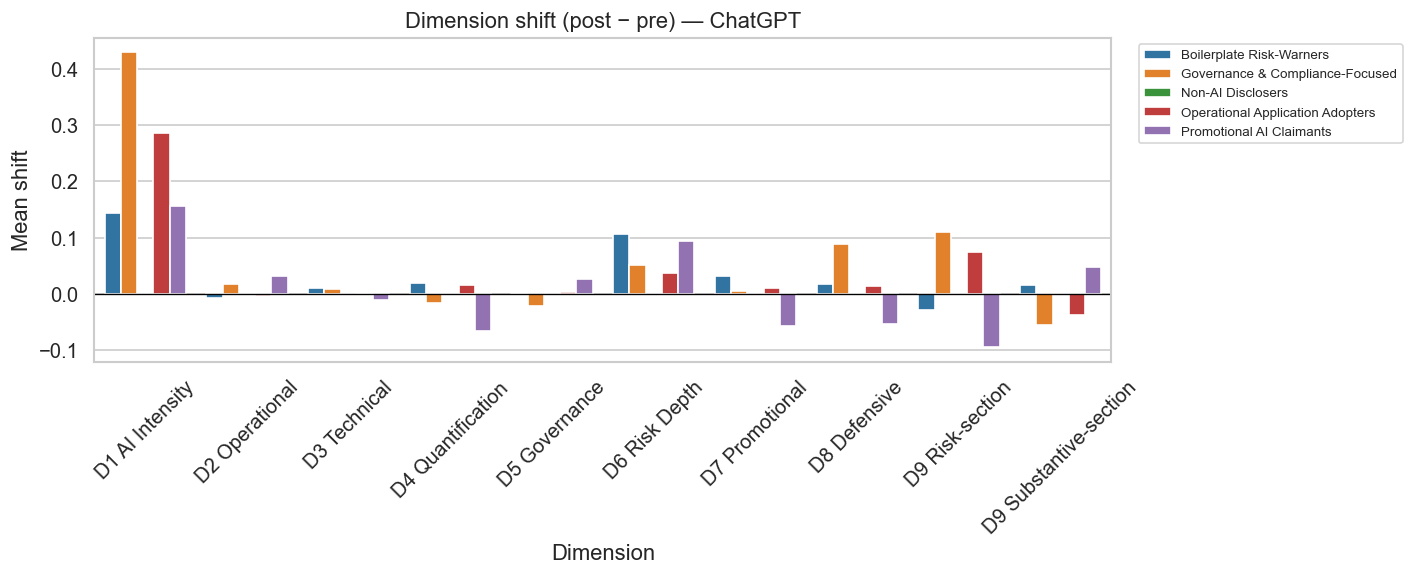

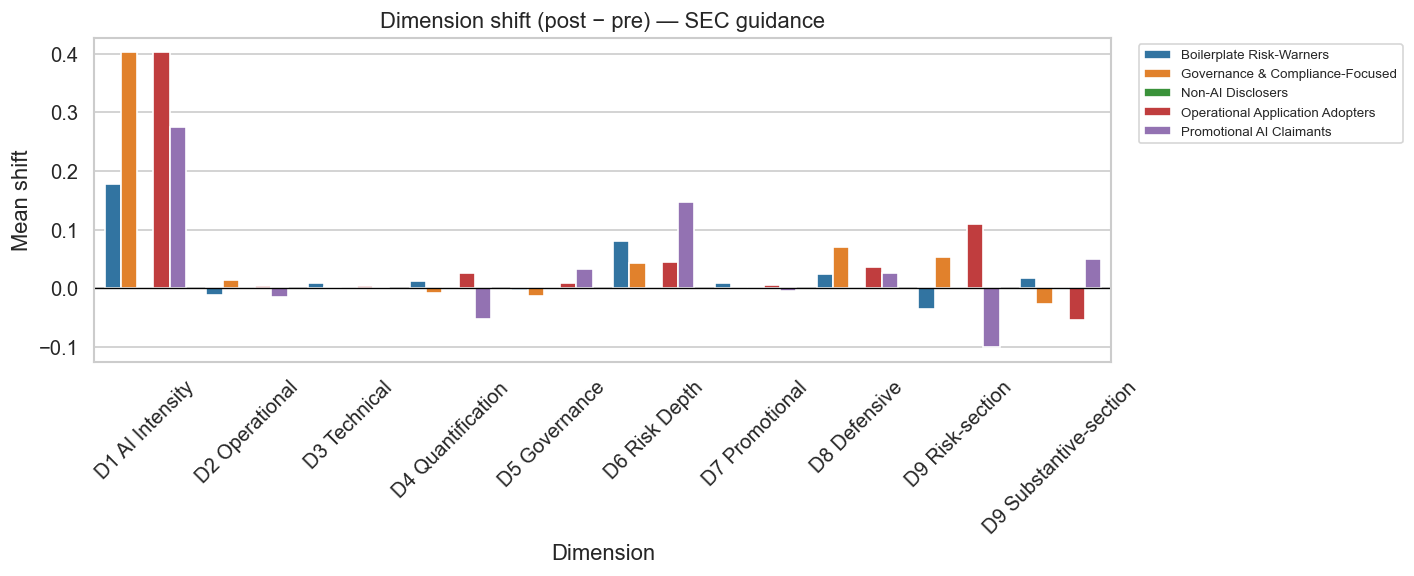

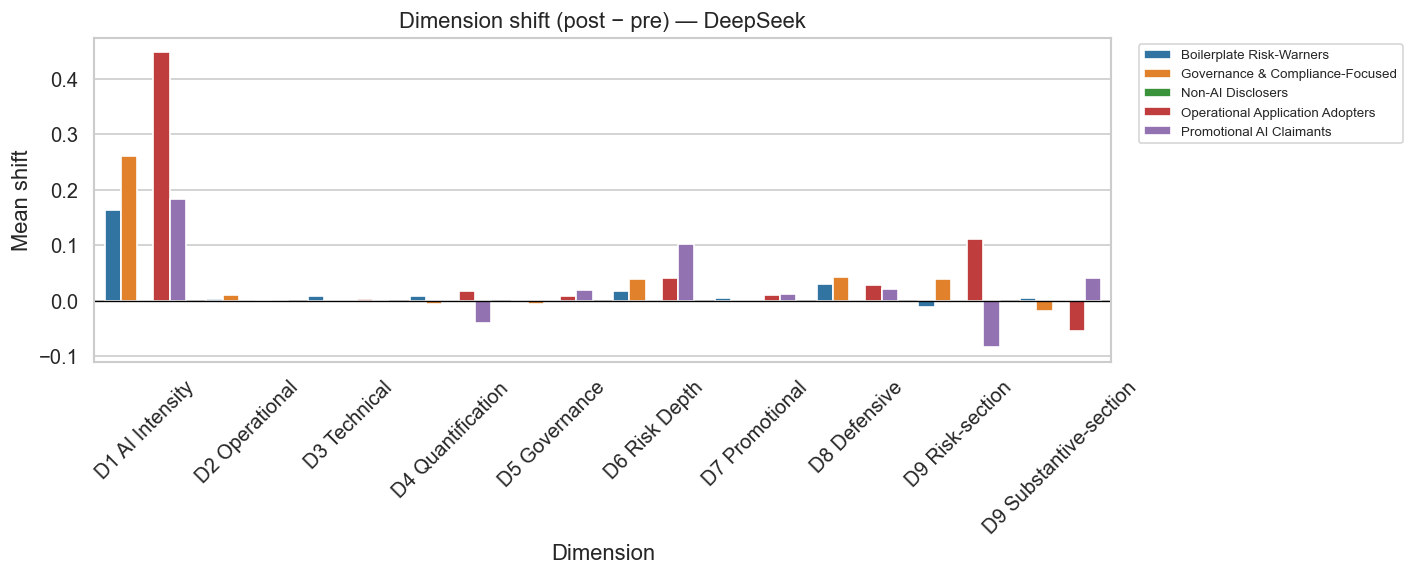

In [10]:
shifts = []
for event_yr, (event_label, _) in EVENTS.items():
    pre  = clusters[clusters['year'] <  event_yr]
    post = clusters[clusters['year'] >= event_yr]
    for dim in DIM_COLS:
        pre_m  = pre.groupby('cluster_name')[dim].mean()
        post_m = post.groupby('cluster_name')[dim].mean()
        delta  = (post_m - pre_m).reset_index()
        delta.columns = ['cluster_name', 'delta']
        delta['event']     = event_label
        delta['dimension'] = dim
        shifts.append(delta)

shifts_df = pd.concat(shifts, ignore_index=True)

for event_label in [e for e, _ in EVENTS.values()]:
    sub = shifts_df[shifts_df['event'] == event_label]
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=sub, x='dimension', y='delta', hue='cluster_name',
                palette='tab10', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Dimension shift (post − pre) — {event_label}')
    ax.set_xlabel('Dimension'); ax.set_ylabel('Mean shift')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'../reports/dim_shift_{event_label.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Alluvial chart — firm migration across archetypes

Shows how individual firms moved between archetypes year over year.

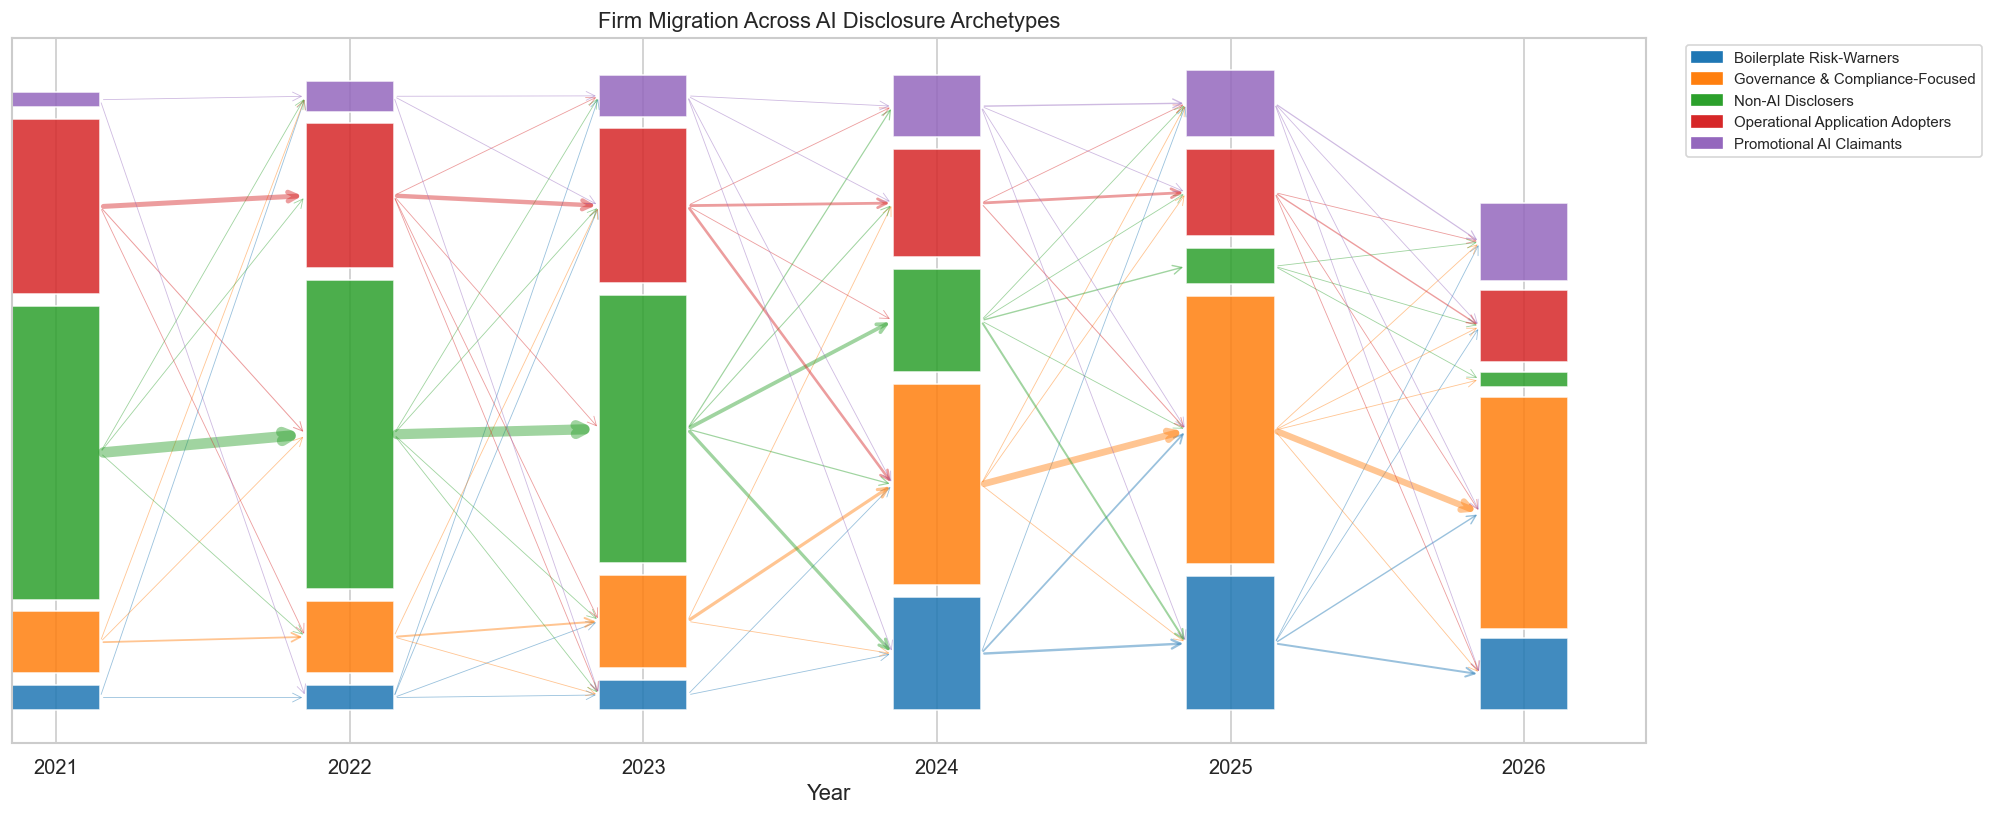

In [5]:
import matplotlib.patches as mpatches

archetype_colors = {
    a: c for a, c in zip(
        sorted(clusters['cluster_name'].unique()),
        sns.color_palette('tab10', clusters['cluster_name'].nunique())
    )
}
YEARS = sorted(clusters['year'].unique())

def alluvial(df, col='cluster_name', years=None, ax=None, palette=None):
    if years is None:
        years = sorted(df['year'].unique())
    archetypes = sorted(df[col].unique())
    colors = palette or {a: c for a, c in zip(archetypes, sns.color_palette('tab10', len(archetypes)))}

    counts = df.groupby(['year', col]).size().unstack(fill_value=0)
    for a in archetypes:
        if a not in counts.columns:
            counts[a] = 0

    positions = {}
    for yr in years:
        total = counts.loc[yr].sum()
        y = 0
        positions[yr] = {}
        for arch in archetypes:
            n = counts.loc[yr, arch]
            positions[yr][arch] = (y, y + n)
            y += n + max(total * 0.02, 1)

    bar_w = 0.3
    for i, yr in enumerate(years):
        for arch in archetypes:
            y0, y1 = positions[yr][arch]
            if y1 > y0:
                ax.barh(y=(y0+y1)/2, width=bar_w, height=y1-y0,
                        left=i - bar_w/2, color=colors[arch], alpha=0.85)

    for i in range(len(years) - 1):
        yr0, yr1 = years[i], years[i+1]
        left  = df[df['year'] == yr0][['ticker', col]].rename(columns={col: 'from_arch'})
        right = df[df['year'] == yr1][['ticker', col]].rename(columns={col: 'to_arch'})
        flows = left.merge(right, on='ticker').groupby(['from_arch','to_arch']).size().reset_index(name='n')
        for _, row in flows.iterrows():
            fa, ta, n = row['from_arch'], row['to_arch'], row['n']
            if fa not in positions[yr0] or ta not in positions[yr1]:
                continue
            ym0 = sum(positions[yr0][fa]) / 2
            ym1 = sum(positions[yr1][ta]) / 2
            ax.annotate('', xy=(i + 1 - bar_w/2, ym1), xytext=(i + bar_w/2, ym0),
                        arrowprops=dict(arrowstyle='->', color=colors[fa],
                                        lw=max(0.5, n * 0.12), alpha=0.45))

    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years)
    ax.set_yticks([])
    ax.set_xlabel('Year')

fig, ax = plt.subplots(figsize=(len(YEARS) * 2.8, 7))
alluvial(clusters, years=YEARS, ax=ax, palette=archetype_colors)
ax.set_title('Firm Migration Across AI Disclosure Archetypes')
patches = [mpatches.Patch(color=c, label=a) for a, c in archetype_colors.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/archetype_alluvial.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Firms that changed archetype post-SEC 2024

Firms with archetype change 2023→2024: 58 / 114

ticker                        arch_2023                        arch_2024  changed
   FDX         Boilerplate Risk-Warners  Governance & Compliance-Focused     True
   NET         Boilerplate Risk-Warners  Governance & Compliance-Focused     True
  RIVN         Boilerplate Risk-Warners  Governance & Compliance-Focused     True
   COF  Governance & Compliance-Focused         Boilerplate Risk-Warners     True
  PANW  Governance & Compliance-Focused Operational Application Adopters     True
  AMGN                Non-AI Disclosers         Promotional AI Claimants     True
    BA                Non-AI Disclosers  Governance & Compliance-Focused     True
  BIIB                Non-AI Disclosers         Boilerplate Risk-Warners     True
     C                Non-AI Disclosers  Governance & Compliance-Focused     True
  CHTR                Non-AI Disclosers         Boilerplate Risk-Warners     True
    CL                Non-AI Disclosers         B

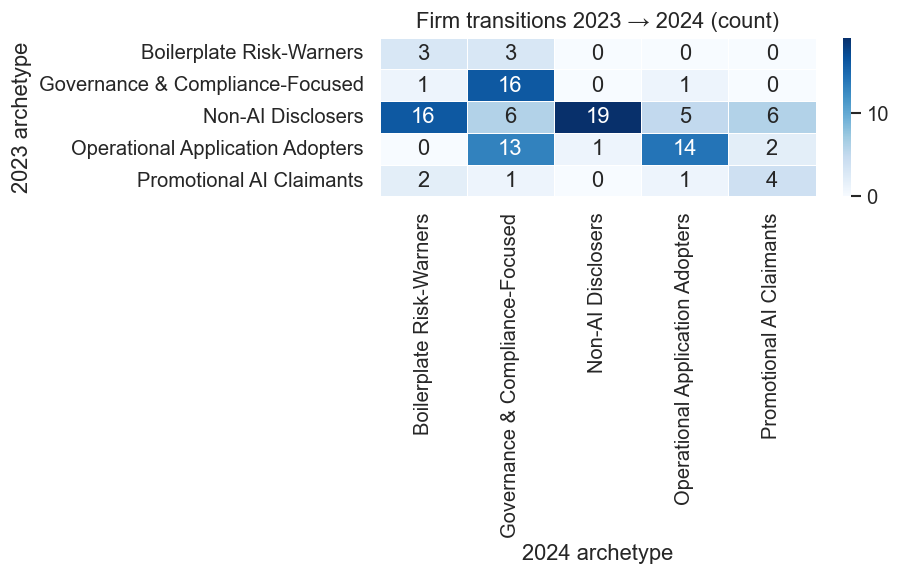

In [11]:
before = clusters[clusters['year'] == 2023][['ticker', 'cluster_name']].rename(columns={'cluster_name': 'arch_2023'})
after  = clusters[clusters['year'] == 2024][['ticker', 'cluster_name']].rename(columns={'cluster_name': 'arch_2024'})

migration = before.merge(after, on='ticker')
migration['changed'] = migration['arch_2023'] != migration['arch_2024']

print(f'Firms with archetype change 2023→2024: {migration["changed"].sum()} / {len(migration)}')
print()
movers = migration[migration['changed']].sort_values('arch_2023')
print(movers.to_string(index=False))

ct = pd.crosstab(migration['arch_2023'], migration['arch_2024'])
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.3)
ax.set_title('Firm transitions 2023 → 2024 (count)')
ax.set_xlabel('2024 archetype'); ax.set_ylabel('2023 archetype')
plt.tight_layout()
plt.savefig('../reports/archetype_transition_2023_2024.png', dpi=150, bbox_inches='tight')
plt.show()
